# Member 1: data preparation and EDA

Owns Sections 1–3.

This notebook is part of the same stage-classification workflow. It uses the original fixed split and settings. Run cells from top to bottom. The original filtering/transformation of CpGs, SEX mapping and AGE units remain unverified. These are exploratory candidate markers, not validated clinical biomarkers.

In Colab, start a fresh CPU runtime and run all cells in order. The setup cell aligns scikit-learn to 1.8.0. The input cell downloads `Xsurv.csv` directly from this GitHub repository and falls back to a Colab upload picker only if needed. No manual path edits are required.

Input: `Xsurv.csv`. Outputs: `development.joblib` for Members 2 and 3 and `test_holdout.joblib` for Member 3. The holdout is kept out of the modeling notebook. The generated checkpoint files can be uploaded to the repository root so the later member notebooks can retrieve them automatically.

## Colab setup and input loading
Run these cells first. Required repository inputs are downloaded automatically from GitHub when they are not already present. Existing local files are reused.


In [1]:
# Run this cell first, before importing analysis packages.
import sys
import subprocess
import importlib.util
from importlib.metadata import version, PackageNotFoundError

try:
    from google.colab import files as colab_files
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# All three members use this version to share fitted scikit-learn models.
TARGET_SKLEARN = '1.8.0'
try:
    installed_sklearn = version('scikit-learn')
except PackageNotFoundError:
    installed_sklearn = None

requirements = []
if installed_sklearn != TARGET_SKLEARN:
    requirements.append('scikit-learn==' + TARGET_SKLEARN)
for module, package in [('numpy','numpy'), ('pandas','pandas'), ('scipy','scipy'),
                        ('matplotlib','matplotlib'), ('seaborn','seaborn'), ('joblib','joblib')]:
    if importlib.util.find_spec(module) is None:
        requirements.append(package)
if requirements:
    # If you already imported a different sklearn version, start a fresh session first.
    if 'sklearn' in sys.modules and installed_sklearn != TARGET_SKLEARN:
        raise RuntimeError('Start a fresh runtime/session and run this setup cell first.')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *requirements])
    importlib.invalidate_caches()
print('Environment:', 'Google Colab' if IN_COLAB else 'Local Python')
print('scikit-learn:', version('scikit-learn'))


Environment: Local Python
scikit-learn: 1.8.0


In [2]:
from pathlib import Path
from urllib.request import urlopen
import io
import pandas as pd

REPO_RAW_BASE = 'https://raw.githubusercontent.com/UmairSeemab/CRG-groupProject/main'
REPO_INPUT_URLS = {
    'Xsurv.csv': f'{REPO_RAW_BASE}/Xsurv.csv',
    'development.joblib': f'{REPO_RAW_BASE}/development.joblib',
    'test_holdout.joblib': f'{REPO_RAW_BASE}/test_holdout.joblib',
    'locked_models.joblib': f'{REPO_RAW_BASE}/locked_models.joblib',
}

def locate_input(filename):
    return next((p for p in [Path('checkpoints') / filename, Path(filename)] if p.is_file()), None)

def validate_csv_bytes(payload):
    candidate = pd.read_csv(io.BytesIO(payload), index_col=0)
    if len(candidate) != 320 or not {'AGE', 'SEX', 'Stage'}.issubset(candidate.columns):
        raise ValueError('This is not the expected 320-row Xsurv dataset.')
    if sum(str(c).startswith('cg') for c in candidate.columns) != 197:
        raise ValueError('Expected 197 CpG columns.')
    if set(candidate.Stage.unique()) != {1, 2}:
        raise ValueError('Expected Stage labels 1 and 2.')
    return candidate

def _download_target(filename):
    if filename.endswith('.joblib'):
        Path('checkpoints').mkdir(exist_ok=True)
        return Path('checkpoints') / filename
    return Path(filename)

def download_repo_input(filename):
    url = REPO_INPUT_URLS.get(filename)
    if url is None:
        return False
    try:
        with urlopen(url, timeout=60) as response:
            payload = response.read()
        if filename == 'Xsurv.csv':
            validate_csv_bytes(payload)
        target = _download_target(filename)
        target.write_bytes(payload)
        print(f'Downloaded {filename} from the project GitHub repository.')
        return True
    except Exception as exc:
        print(f'Automatic download failed for {filename}: {exc}')
        return False

def ensure_inputs(required):
    missing = [name for name in required if locate_input(name) is None]

    # First try the public files stored in this GitHub repository.
    for name in list(missing):
        download_repo_input(name)
    missing = [name for name in required if locate_input(name) is None]

    # Fallback for Colab if GitHub is temporarily unavailable or a file has not been uploaded yet.
    if missing and IN_COLAB:
        print('GitHub input unavailable. Upload these files together:', ', '.join(missing))
        uploaded = colab_files.upload()
        for name, payload in uploaded.items():
            filename = Path(name).name
            if filename in required:
                target = _download_target(filename)
                target.write_bytes(payload)
        missing = [name for name in required if locate_input(name) is None]

    if missing:
        raise FileNotFoundError(
            'Required inputs still missing: ' + ', '.join(missing) +
            '. Upload them to the repository root, place them beside the notebook/checkpoints folder, '
            'or rerun this cell and use the Colab upload fallback.'
        )

    if 'Xsurv.csv' in required:
        validate_csv_bytes(locate_input('Xsurv.csv').read_bytes())
    print('Inputs ready:', ', '.join(required))

ensure_inputs(['Xsurv.csv'])


Inputs ready: Xsurv.csv


In [3]:
from pathlib import Path
import sys, json, hashlib, platform, warnings
import numpy as np
import pandas as pd
import scipy, sklearn, matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.base import clone
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import (roc_auc_score, balanced_accuracy_score, recall_score,
                             confusion_matrix, roc_curve, precision_recall_curve,
                             average_precision_score, brier_score_loss)
from sklearn.exceptions import ConvergenceWarning

SEED = 42
DATA_PATH = locate_input('Xsurv.csv')
OUT = Path('Xsurv_results/member_1')
OUT.mkdir(exist_ok=True, parents=True)
OUTER_FOLDS, INNER_FOLDS = 5, 3
N_BOOTSTRAP = 2000
THRESHOLD = 0.5  # fixed in advance; never optimize on the test set
PANEL_TOLERANCE = 0.02  # descriptive AUC tolerance, not a noninferiority margin
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams.update({'figure.dpi': 110, 'savefig.dpi': 180, 'font.size': 10})
versions = {'python': platform.python_version(), 'numpy': np.__version__,
            'pandas': pd.__version__, 'scipy': scipy.__version__,
            'scikit-learn': sklearn.__version__, 'matplotlib': matplotlib.__version__,
            'seaborn': sns.__version__}
print(json.dumps(versions, indent=2))
def table(obj):
    print(obj.to_string() if hasattr(obj, 'to_string') else obj)
def finish(name):
    plt.tight_layout()
    plt.savefig(OUT / (name + '.png'), bbox_inches='tight')
    plt.show()
# Do not silently accept a nonconverged logistic model.
warnings.filterwarnings('error', category=ConvergenceWarning)
import joblib
CHECKPOINTS = Path('checkpoints')
CHECKPOINTS.mkdir(exist_ok=True)
def load_checkpoint(filename):
    path = next((p for p in [CHECKPOINTS/filename, Path(filename)] if p.exists()), None)
    if path is None:
        raise FileNotFoundError(f'Upload {filename} or put it in checkpoints/. Run the preceding member notebook first.')
    # Load only checkpoint files produced by your trusted group: joblib uses pickle.
    bundle = joblib.load(path)
    if bundle['versions']['scikit-learn'] != sklearn.__version__:
        raise RuntimeError('Use the same scikit-learn version as the checkpoint creator: '+bundle['versions']['scikit-learn'])
    return bundle

{
  "python": "3.12.14",
  "numpy": "2.3.5",
  "pandas": "2.2.3",
  "scipy": "1.17.0",
  "scikit-learn": "1.8.0",
  "matplotlib": "3.10.8",
  "seaborn": "0.13.2"
}


## 1. Load and audit the dataset
The first CSV column is a row identifier, not a predictor. We verify the expected structure, missingness, duplicate records and numeric values. SEX remains an unnamed binary code because its category mapping is unavailable. AGE units are also unverified. We do not guess or remove unusual ages.

CpG values outside [0, 1] cannot be raw methylation beta values. Negative values alone do not tell us whether these are standardized values, M-values, or another transformation.

In [4]:
if DATA_PATH is None:
    candidates = [Path('Xsurv.csv'), Path('../data/Xsurv.csv'), Path('../upload/Xsurv.csv')]
    DATA_PATH = next((p for p in candidates if p.exists()), None)
if DATA_PATH is None or not Path(DATA_PATH).exists():
    raise FileNotFoundError('Set DATA_PATH to the supplied Xsurv.csv.')
DATA_PATH = Path(DATA_PATH)
df = pd.read_csv(DATA_PATH, index_col=0)
cpgs = [c for c in df if c.startswith('cg')]
clinical = ['AGE', 'SEX']
assert {'AGE', 'SEX', 'Stage'}.issubset(df.columns)
assert set(df.Stage.unique()) == {1, 2}
assert df.index.is_unique and df.columns.is_unique
assert df.select_dtypes(include='number').shape[1] == df.shape[1]
assert np.isfinite(df.to_numpy()).all(), 'Missing/nonfinite values need a training-only imputer.'
assert not df.duplicated().any(), 'Review duplicates before splitting.'
audit = pd.Series({'rows': len(df), 'variables': df.shape[1], 'CpGs': len(cpgs),
                   'missing_values': int(df.isna().sum().sum()),
                   'constant_columns': int((df.nunique() <= 1).sum()),
                   'AGE_min': df.AGE.min(), 'AGE_max': df.AGE.max(),
                   'CpG_min': df[cpgs].min().min(), 'CpG_max': df[cpgs].max().max()})
table(audit)
table(df.iloc[:5, :7])
print('SEX codes:', sorted(df.SEX.unique()))
print('Dataset SHA256:', hashlib.sha256(DATA_PATH.read_bytes()).hexdigest())

rows                320.000000
variables           200.000000
CpGs                197.000000
missing_values        0.000000
constant_columns      0.000000
AGE_min               1.000000
AGE_max              69.000000
CpG_min              -1.387389
CpG_max               1.376260
    SEX  AGE  Stage  cg27248148  cg12058490  cg00241712  cg16118089
1     2   53      1    0.688097    0.897329    1.019083   -0.924499
2     2   64      1   -0.167593    0.187312    0.420220   -0.332361
3     2   64      2   -0.107404    0.876143    0.207461   -0.462419
21    1   22      2    0.224873    0.704260    0.027405   -0.663955
28    1   61      2   -0.383246   -0.067605    0.187677   -0.301763
SEX codes: [np.int64(1), np.int64(2)]
Dataset SHA256: 06760b806726a4a5cc11aebef35e5630e7817f93bee60f169563b7d26a6c0d99


## 2. Reserve the test set before exploration
We recode low stage to 0 and high stage to 1, so all positive-class metrics refer to high stage. The 80/20 split is stratified. Test labels are used here only to preserve and report class counts. Test predictors are not explored or fitted until the final evaluation.

This is an internal held-out test set from the same dataset, not an independent external cohort.

            Development  Test
Low stage           126    31
High stage          130    33


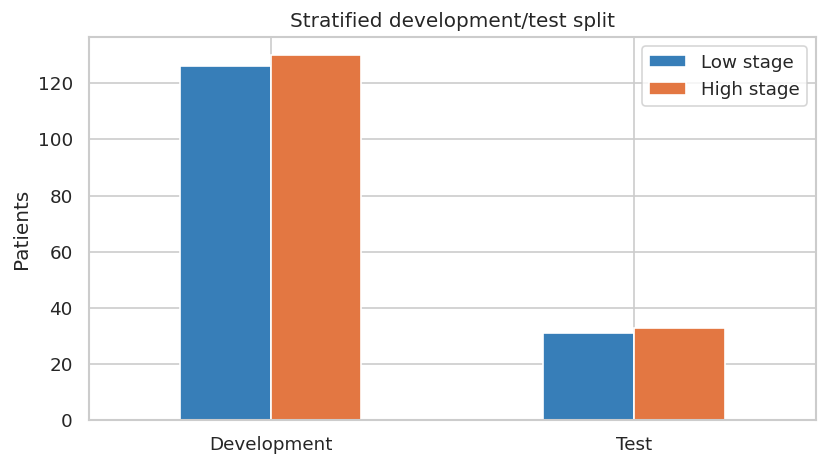

In [5]:
X = df[clinical + cpgs].copy()
y = df.Stage.map({1: 0, 2: 1}).astype(int)
X_dev, X_test, y_dev, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=SEED)
assert set(X_dev.index).isdisjoint(X_test.index)
counts = pd.DataFrame({'Development': y_dev.value_counts(), 'Test': y_test.value_counts()})
counts = counts.reindex([0, 1])
counts.index = ['Low stage', 'High stage']
table(counts)
counts.T.plot(kind='bar', color=['#377eb8', '#e37742'], rot=0, figsize=(7, 4))
plt.ylabel('Patients'); plt.title('Stratified development/test split')
finish('01_split')
split_manifest = pd.DataFrame({'row_id': df.index, 'partition': np.where(df.index.isin(X_dev.index), 'development', 'test')})

## 3. Explore development patients only
The following plots describe the development set. A PCA separation is exploratory and is not a predictive-performance estimate. PCA uses CpGs only, so age and sex cannot dominate the axes. Its fitted scaler and components are not reused by the classifiers.

Development-only pairs with |r| > 0.9:
        CpG_1       CpG_2  Pearson_r
0  cg25671438  cg02210967   0.912752
1  cg14649566  cg11496569   0.915941


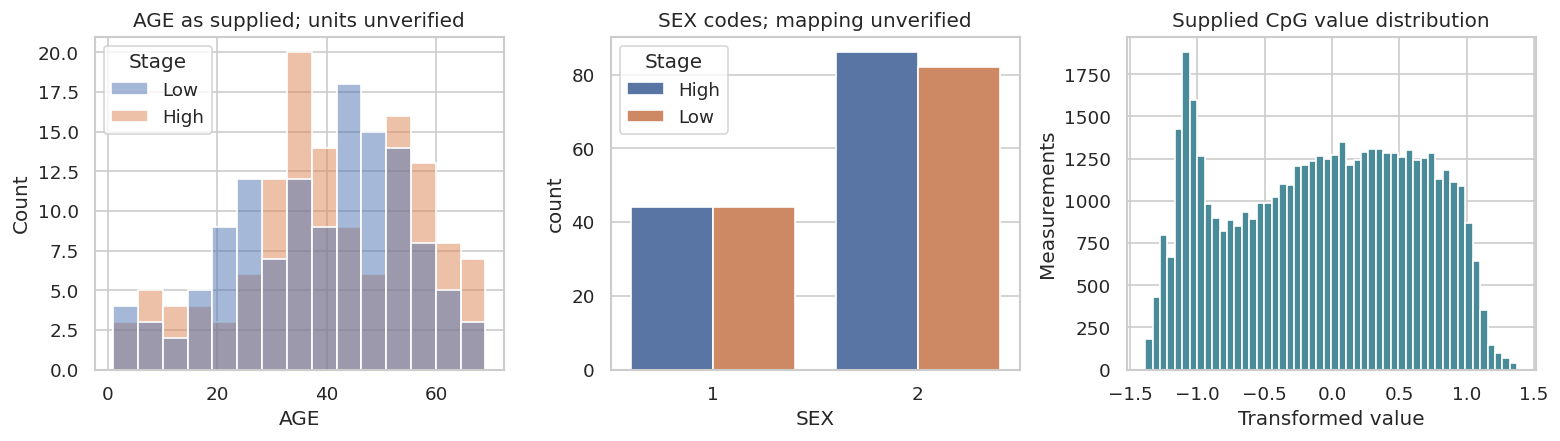

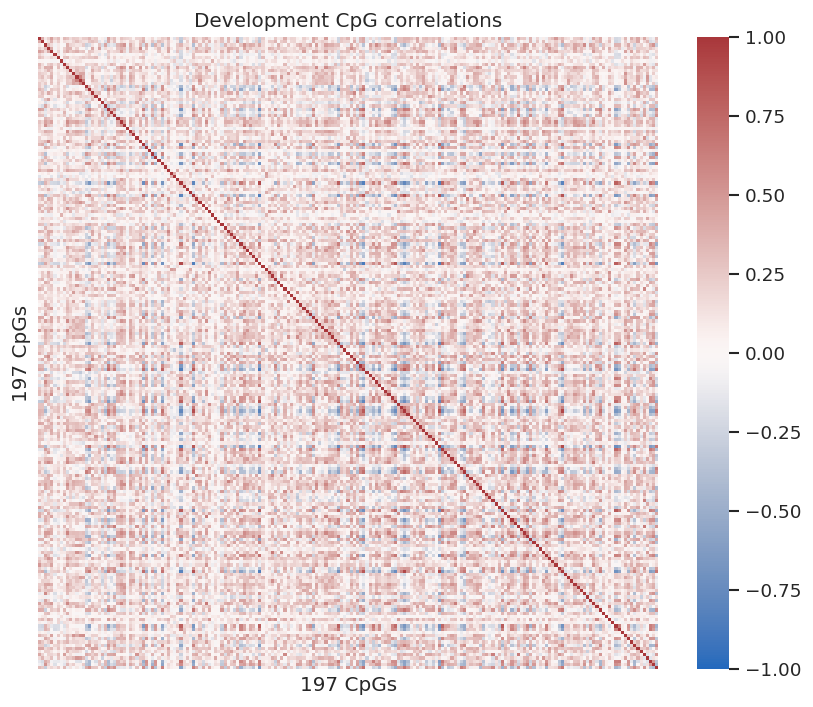

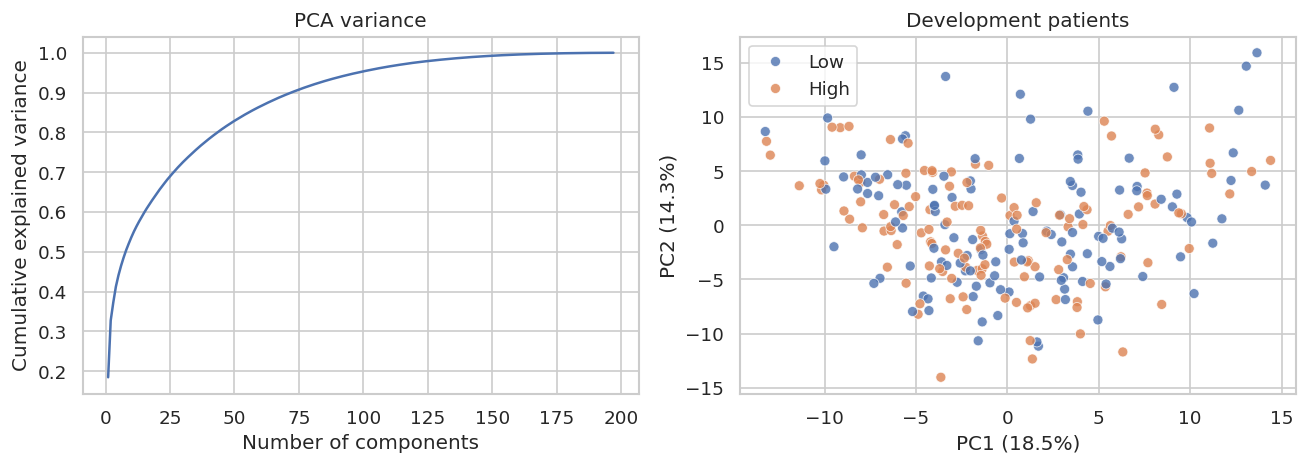

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
sns.histplot(data=X_dev.assign(Stage=y_dev.map({0:'Low', 1:'High'})), x='AGE', hue='Stage', bins=15, ax=axes[0])
axes[0].set_title('AGE as supplied; units unverified')
sns.countplot(data=X_dev.assign(Stage=y_dev.map({0:'Low', 1:'High'})), x='SEX', hue='Stage', ax=axes[1])
axes[1].set_title('SEX codes; mapping unverified')
axes[2].hist(X_dev[cpgs].to_numpy().ravel(), bins=50, color='#498b99')
axes[2].set(title='Supplied CpG value distribution', xlabel='Transformed value', ylabel='Measurements')
finish('02_distributions')

corr = X_dev[cpgs].corr()
upper = corr.where(np.triu(np.ones(corr.shape, dtype=bool), k=1)).stack()
high_corr = upper[upper.abs() > 0.9].rename('Pearson_r').reset_index()
high_corr.columns = ['CpG_1', 'CpG_2', 'Pearson_r']
print('Development-only pairs with |r| > 0.9:'); table(high_corr)
plt.figure(figsize=(7, 6))
sns.heatmap(corr, cmap='vlag', center=0, vmin=-1, vmax=1, xticklabels=False, yticklabels=False)
plt.title('Development CpG correlations'); plt.xlabel('197 CpGs'); plt.ylabel('197 CpGs')
finish('03_correlations')

pca = PCA()
z = StandardScaler().fit_transform(X_dev[cpgs])
pcs = pca.fit_transform(z)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(np.arange(1, len(pca.explained_variance_ratio_)+1), np.cumsum(pca.explained_variance_ratio_))
axes[0].set(xlabel='Number of components', ylabel='Cumulative explained variance', title='PCA variance')
sns.scatterplot(x=pcs[:,0], y=pcs[:,1], hue=y_dev.map({0:'Low',1:'High'}).to_numpy(), ax=axes[1], alpha=0.8)
axes[1].set(xlabel=f'PC1 ({pca.explained_variance_ratio_[0]:.1%})', ylabel=f'PC2 ({pca.explained_variance_ratio_[1]:.1%})', title='Development patients')
finish('04_pca')

## Handoff: save the fixed split
The development checkpoint contains no test predictors or test labels. Send the separate holdout checkpoint only to Member 3. Both files share a dataset fingerprint and split identifier so mixed runs can be detected.

In [7]:
source_hash = hashlib.sha256(DATA_PATH.read_bytes()).hexdigest()
config = {'seed':SEED, 'outer_folds':OUTER_FOLDS, 'inner_folds':INNER_FOLDS,
          'threshold':THRESHOLD, 'panel_tolerance':PANEL_TOLERANCE, 'n_bootstrap':N_BOOTSTRAP}
split_id = hashlib.sha256((source_hash + json.dumps(config,sort_keys=True) + json.dumps(X_dev.index.tolist())).encode()).hexdigest()
common = {'versions':versions, 'source_hash':source_hash, 'split_id':split_id, 'config':config}
development = {**common,'X_dev':X_dev,'y_dev':y_dev,'clinical':clinical,'cpgs':cpgs,
               'audit':audit,'split_manifest':split_manifest,'high_corr':high_corr}
holdout = {**common,'X_test':X_test,'y_test':y_test}
joblib.dump(development,CHECKPOINTS/'development.joblib')
joblib.dump(holdout,CHECKPOINTS/'test_holdout.joblib')
audit.rename('value').to_csv(OUT/'data_audit.csv')
split_manifest.to_csv(OUT/'split_manifest.csv',index=False)
high_corr.to_csv(OUT/'high_correlations_development.csv',index=False)
print('Send checkpoints/development.joblib to Members 2 and 3.')
print('Send checkpoints/test_holdout.joblib to Member 3 only.')
print('Split identifier:',split_id)

Send checkpoints/development.joblib to Members 2 and 3.
Send checkpoints/test_holdout.joblib to Member 3 only.
Split identifier: 890e3b671a04f0b2d22052aa026d6f49d63ed6b195e81040c93b0b5b1c4fb9ca


## References and interpretation guide
- Input data: user-supplied `Xsurv.csv`; starting specification: `project_Xsurv.ipynb`. The original notebook cites [Efficient gradient boosting for prognostic biomarker discovery](https://doi.org/10.1093/bioinformatics/btab869). This notebook analyzes the supplied stage outcome only; it does not reproduce that survival study.
- [scikit-learn: common pitfalls and data leakage](https://scikit-learn.org/stable/common_pitfalls.html): fit preprocessing and feature selection using training partitions only.
- [scikit-learn: nested versus non-nested cross-validation](https://scikit-learn.org/stable/auto_examples/model_selection/plot_nested_cross_validation_iris.html): separate tuning from outer-fold assessment.

**Reading the figures:** PCA shows major variation, not validated classification. Fold dots show sensitivity to the training split. Selection frequency shows reproducibility within these development folds. Coefficient signs describe the fitted conditional association. ROC/precision–recall curves evaluate the locked models on held-out patients. Bootstrap intervals describe uncertainty in those test patients, conditional on the trained models.

**Before a scientific claim:** verify independent patients, original filtering and normalization, AGE/SEX metadata, assay annotations and external replication. A compact panel that performs poorly is still an informative result; do not relabel it as a validated biomarker panel.

## Download your results and handoffs
In Colab, this cell downloads your results archive and any checkpoints generated by your part. Allow multiple downloads if your browser asks. You can also download individual files through Colab’s Files panel.

In [8]:
# Optional: run this cell to download outputs before ending your Colab session.
import shutil
archive = shutil.make_archive('member_1_results', 'zip', str(OUT))
if IN_COLAB:
    colab_files.download(archive)
    for filename in ['development.joblib', 'test_holdout.joblib']:
        colab_files.download(str(CHECKPOINTS/filename))
else:
    print('Results archive:', archive)


Results archive: /workspace/scratch/f1a0843b0c79/group_split/member_1_results.zip
